In [7]:
"""
Influencer Demand Forecasting — Synthetic Dataset Generator  (v3)
==================================================================
Generates a realistic training dataset for predicting demand lift
after a Williams-Sonoma influencer post.

Changes from v2
---------------
- N_ROWS         : 10,000  (from 500)
- Date spread    : 48 months / 4 years  (from 24 months)
- Influencers    : 58  (from 29) — doubled across all tiers
- Products       : 12  (from 6)  — added 6 new WS-style SKUs
- Seasonal boost : stronger month-based demand multiplier
- Noise          : slightly more realistic per-row noise

Output files
------------
  influencer_posts.csv        — post + influencer features  (no labels)
  product_catalog.csv         — product-level static features
  demand_labels.csv           — target labels
  training_dataset_full.csv   — joined model-ready dataset

Run
---
  pip install pandas numpy
  python generate_dataset.py
"""

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings("ignore")

SEED       = 42
N_ROWS     = 10_000
WS_RATE    = 0.55
OUTPUT_DIR = "."

np.random.seed(SEED)
random.seed(SEED)

# ── Influencer pool (58 influencers) ─────────────────────────────────────────
INFLUENCERS = [
    # ── Celebrity (8) ──────────────────────────────────────────────────────
    ("@chrissy.homes",      "celebrity", (8_000_000, 15_000_000), (0.005, 0.012), 3.20, "Instagram"),
    ("@luxe.by.serena",     "celebrity", (6_000_000, 12_000_000), (0.006, 0.013), 2.90, "Instagram"),
    ("@thehomeguru",        "celebrity", (7_000_000, 14_000_000), (0.005, 0.011), 3.50, "YouTube"),
    ("@domesticbliss_hq",   "celebrity", (5_000_000, 10_000_000), (0.007, 0.014), 2.60, "TikTok"),
    ("@cozyworldtv",        "celebrity", (9_000_000, 18_000_000), (0.004, 0.010), 3.10, "YouTube"),
    ("@thehomeeditor",      "celebrity", (7_500_000, 13_000_000), (0.005, 0.012), 2.80, "Instagram"),
    ("@modernhome.star",    "celebrity", (6_500_000, 11_000_000), (0.006, 0.013), 3.00, "TikTok"),
    ("@kitchen.royale",     "celebrity", (8_500_000, 16_000_000), (0.004, 0.011), 3.30, "YouTube"),
    # ── Mega (10) ─────────────────────────────────────────────────────────
    ("@luxe_home_vida",     "mega", (1_500_000, 5_000_000), (0.010, 0.025), 1.80, "Instagram"),
    ("@thewarmhome",        "mega", (2_000_000, 4_500_000), (0.012, 0.022), 2.10, "Instagram"),
    ("@houseofwarm",        "mega", (3_000_000, 5_500_000), (0.014, 0.020), 2.40, "TikTok"),
    ("@lifestyle.lux",      "mega", (1_800_000, 4_000_000), (0.010, 0.018), 1.20, "Instagram"),
    ("@winterwears",        "mega", (1_200_000, 3_000_000), (0.015, 0.025), 1.50, "TikTok"),
    ("@velvet.interiors",   "mega", (2_200_000, 4_800_000), (0.011, 0.021), 2.00, "Instagram"),
    ("@the.lux.table",      "mega", (1_600_000, 3_800_000), (0.013, 0.023), 1.70, "YouTube"),
    ("@homecraft.mega",     "mega", (2_500_000, 5_000_000), (0.012, 0.020), 1.90, "Instagram"),
    ("@cozyhaven.co",       "mega", (1_400_000, 3_500_000), (0.014, 0.024), 1.60, "TikTok"),
    ("@designedbyella",     "mega", (1_900_000, 4_200_000), (0.010, 0.019), 2.20, "YouTube"),
    # ── Mid (16) ──────────────────────────────────────────────────────────
    ("@nordic.nest",        "mid", (300_000,  800_000), (0.028, 0.048), 0.95, "Instagram"),
    ("@decor.daily",        "mid", (400_000,  900_000), (0.030, 0.050), 1.10, "Instagram"),
    ("@diwali.glow",        "mid", (250_000,  700_000), (0.032, 0.055), 1.20, "TikTok"),
    ("@fashion.fwd99",      "mid", (350_000,  750_000), (0.025, 0.045), 0.40, "Instagram"),
    ("@ootd.vibes",         "mid", (280_000,  650_000), (0.030, 0.052), 0.30, "TikTok"),
    ("@stylehaus",          "mid", (400_000,  850_000), (0.028, 0.046), 0.35, "YouTube"),
    ("@kitchenlove.co",     "mid", (320_000,  780_000), (0.031, 0.051), 1.05, "Instagram"),
    ("@bakedwithlove",      "mid", (270_000,  720_000), (0.029, 0.049), 0.95, "YouTube"),
    ("@slate.and.oak",      "mid", (310_000,  760_000), (0.030, 0.050), 1.00, "Instagram"),
    ("@morningbrew.home",   "mid", (360_000,  820_000), (0.027, 0.047), 0.90, "TikTok"),
    ("@the.linen.room",     "mid", (290_000,  730_000), (0.031, 0.053), 1.15, "Instagram"),
    ("@supper.club.co",     "mid", (340_000,  800_000), (0.029, 0.049), 1.00, "YouTube"),
    ("@ambiance.daily",     "mid", (260_000,  680_000), (0.033, 0.055), 0.85, "Instagram"),
    ("@warmth.and.wool",    "mid", (380_000,  870_000), (0.028, 0.046), 1.05, "TikTok"),
    ("@foraged.table",      "mid", (305_000,  755_000), (0.030, 0.051), 0.80, "YouTube"),
    ("@modernhearth",       "mid", (375_000,  840_000), (0.027, 0.045), 0.95, "Instagram"),
    # ── Micro (16) ────────────────────────────────────────────────────────
    ("@blanket.queen",      "micro", (100_000, 250_000), (0.045, 0.075), 1.20, "Instagram"),
    ("@cozy.cabin.co",      "micro", (120_000, 280_000), (0.050, 0.080), 1.30, "TikTok"),
    ("@the.throw.life",     "micro", (90_000,  220_000), (0.048, 0.078), 1.10, "Instagram"),
    ("@festive.frames",     "micro", (70_000,  180_000), (0.052, 0.082), 0.80, "Instagram"),
    ("@minimalist.me",      "micro", (60_000,  150_000), (0.055, 0.085), 0.20, "YouTube"),
    ("@cozy.mornings",      "micro", (80_000,  200_000), (0.050, 0.080), 0.25, "TikTok"),
    ("@diwali_diaries",     "micro", (65_000,  170_000), (0.055, 0.085), 0.90, "Instagram"),
    ("@sundaybakes_",       "micro", (95_000,  240_000), (0.047, 0.077), 1.00, "YouTube"),
    ("@thicket.home",       "micro", (85_000,  210_000), (0.049, 0.079), 1.05, "Instagram"),
    ("@salt.and.slate",     "micro", (110_000, 265_000), (0.046, 0.074), 0.95, "TikTok"),
    ("@porcelain.life",     "micro", (75_000,  190_000), (0.051, 0.081), 1.00, "Instagram"),
    ("@linen.and.light",    "micro", (88_000,  215_000), (0.049, 0.079), 1.10, "YouTube"),
    ("@ember.interiors",    "micro", (66_000,  172_000), (0.054, 0.084), 0.85, "TikTok"),
    ("@gathered.table",     "micro", (92_000,  228_000), (0.048, 0.078), 0.95, "Instagram"),
    ("@craft.and.cup",      "micro", (78_000,  195_000), (0.052, 0.082), 0.75, "YouTube"),
    ("@softmorning.co",     "micro", (102_000, 255_000), (0.047, 0.075), 1.15, "Instagram"),
    # ── Nano (8) ──────────────────────────────────────────────────────────
    ("@lights.and.love",    "nano", (10_000, 35_000), (0.070, 0.110), 0.55, "Instagram"),
    ("@home.aesthete",      "nano", (12_000, 40_000), (0.075, 0.115), 0.10, "TikTok"),
    ("@prettynest_",        "nano", (8_000,  28_000), (0.080, 0.120), 0.60, "Instagram"),
    ("@dailynook_",         "nano", (9_500,  32_000), (0.078, 0.118), 0.50, "Instagram"),
    ("@candlelit.home",     "nano", (11_000, 38_000), (0.072, 0.112), 0.45, "TikTok"),
    ("@pressed.petals",     "nano", (7_500,  26_000), (0.082, 0.122), 0.40, "YouTube"),
    ("@quiet.corner.co",    "nano", (13_000, 42_000), (0.070, 0.108), 0.55, "Instagram"),
    ("@tablefor2.home",     "nano", (10_500, 36_000), (0.074, 0.114), 0.35, "TikTok"),
]

PLATFORM_DECAY_MULT = {"TikTok": 1.30, "Instagram": 1.00, "YouTube": 0.70}
TIER_LAMBDA_BASE = {
    "celebrity": 0.45, "mega": 0.38, "mid": 0.31, "micro": 0.27, "nano": 0.22,
}

PRODUCTS = [
    {"product_id":"PT1",  "product_name":"Cozy Blanket Warm Winter Throw",           "product_category":"bedding",             "product_price_usd":79.95,  "base_daily_demand":140, "demand_std_30d":22.0, "historical_avg_lift":1.35, "desc_keywords":["cozy","blanket","warm","winter","throw"],            "typical_hashtags":["#cozy","#blanket","#winter","#throwblanket"]},
    {"product_id":"PT2",  "product_name":"Decorative Diwali Fairy Lights",           "product_category":"decor",               "product_price_usd":49.95,  "base_daily_demand":60,  "demand_std_30d":9.5,  "historical_avg_lift":1.10, "desc_keywords":["decorative","lights","diwali","fairy","festival"],   "typical_hashtags":["#diwali","#fairylights","#festivedecor","#homedecor"]},
    {"product_id":"PT3",  "product_name":"Winter Hoodie Jacket",                     "product_category":"apparel",             "product_price_usd":129.00, "base_daily_demand":95,  "demand_std_30d":14.5, "historical_avg_lift":0.85, "desc_keywords":["winter","hoodie","jacket","fashion"],                "typical_hashtags":["#winterfashion","#hoodie","#ootd","#jacket"]},
    {"product_id":"PT4",  "product_name":"All-Clad Stainless Steel Cookware Set",    "product_category":"cookware",            "product_price_usd":699.95, "base_daily_demand":35,  "demand_std_30d":6.0,  "historical_avg_lift":1.60, "desc_keywords":["cookware","stainless","kitchen","cooking","allclad"],"typical_hashtags":["#cookware","#kitchenupgrade","#homecooking","#allclad"]},
    {"product_id":"PT5",  "product_name":"Marble Wood Serving Board",                "product_category":"entertaining",        "product_price_usd":89.00,  "base_daily_demand":75,  "demand_std_30d":11.0, "historical_avg_lift":1.20, "desc_keywords":["marble","wood","serving","board","entertaining"],    "typical_hashtags":["#charcuterie","#servingboard","#entertaining","#tablescape"]},
    {"product_id":"PT6",  "product_name":"Scented Soy Candle Set Holiday Edition",   "product_category":"home_fragrance",      "product_price_usd":58.00,  "base_daily_demand":110, "demand_std_30d":17.5, "historical_avg_lift":1.45, "desc_keywords":["candle","soy","scented","holiday","fragrance"],      "typical_hashtags":["#soycandle","#homedecor","#holidayvibes","#hygge"]},
    {"product_id":"PT7",  "product_name":"Le Creuset Dutch Oven 5.5 Qt",             "product_category":"cookware",            "product_price_usd":420.00, "base_daily_demand":45,  "demand_std_30d":7.5,  "historical_avg_lift":1.75, "desc_keywords":["lecreuset","dutch","oven","cast","iron"],            "typical_hashtags":["#lecreuset","#dutchoven","#castiron","#homecooking"]},
    {"product_id":"PT8",  "product_name":"Monogrammed Linen Napkin Set",             "product_category":"entertaining",        "product_price_usd":64.00,  "base_daily_demand":55,  "demand_std_30d":8.5,  "historical_avg_lift":1.00, "desc_keywords":["linen","napkin","monogram","table","entertaining"],  "typical_hashtags":["#linens","#tablescape","#entertaining","#homedecor"]},
    {"product_id":"PT9",  "product_name":"Aesop Hand Cream Soap Gift Set",           "product_category":"bath_body",           "product_price_usd":95.00,  "base_daily_demand":80,  "demand_std_30d":12.0, "historical_avg_lift":1.30, "desc_keywords":["aesop","hand","cream","soap","gift"],                "typical_hashtags":["#aesop","#selfcare","#giftset","#luxuryskincare"]},
    {"product_id":"PT10", "product_name":"Faux Fur Accent Pillow Set of 2",          "product_category":"bedding",             "product_price_usd":74.00,  "base_daily_demand":90,  "demand_std_30d":13.5, "historical_avg_lift":1.15, "desc_keywords":["faux","fur","pillow","accent","cozy"],               "typical_hashtags":["#pillows","#cozy","#bedroomdecor","#fauxfur"]},
    {"product_id":"PT11", "product_name":"Nespresso Vertuo Coffee Machine",          "product_category":"kitchen_appliances",  "product_price_usd":199.00, "base_daily_demand":65,  "demand_std_30d":10.0, "historical_avg_lift":1.50, "desc_keywords":["nespresso","coffee","machine","espresso","kitchen"], "typical_hashtags":["#nespresso","#coffeelover","#morningcoffee","#kitchengoals"]},
    {"product_id":"PT12", "product_name":"Woven Seagrass Storage Basket Set",        "product_category":"decor",               "product_price_usd":69.00,  "base_daily_demand":70,  "demand_std_30d":10.5, "historical_avg_lift":1.05, "desc_keywords":["woven","seagrass","basket","storage","boho"],        "typical_hashtags":["#organization","#seagrass","#basketdecor","#homedecor"]},
]

WS_MENTIONS = [
    "Williams-Sonoma","williams-sonoma","@WilliamsSonoma",
    "#WilliamsSonoma","from Williams Sonoma","by Williams-Sonoma",
]
CAPTIONS_WS = [
    "Absolutely obsessed with this {product} I got from {ws} Perfect for the season!",
    "Gifted by {ws} their {product} is everything I needed this {season}.",
    "Finally upgraded my home with this stunning {product} from {ws}. 10/10 recommend!",
    "This {product} from {ws} is pure luxury. My home feels so much cozier now!",
    "Can we talk about how amazing this {product} is? Grabbed it from {ws} last week.",
    "Holiday shopping done right {product} courtesy of {ws}. Link in bio!",
    "In love with my new {product} from {ws}. The quality is unreal!",
    "You NEED this {product} from {ws} in your home right now. Not negotiating.",
    "My {season} home refresh starts with this {product} from {ws}. Obsessed.",
    "Partnered with {ws} to bring you my honest review of their {product}. Worth every penny!",
    "Okay I have to talk about this {product} from {ws}. It completely changed my space.",
    "Running to {ws} for this {product}. Hands down the best {season} purchase yet.",
    "Nothing beats quality like {ws} their {product} just arrived and I am in love!",
    "3 weeks in and I cannot stop raving about this {product} from {ws}. Must have.",
]
CAPTIONS_NO_WS = [
    "Loving this {product} I found recently! Great quality and so comfy.",
    "Perfect {season} vibes with this {product}. What do you think?",
    "Upgraded my home setup with a new {product}. Feeling cozy!",
    "This {product} is exactly what I needed. Highly recommend!",
    "Current mood wrapped in my {product} with a hot cup of coffee.",
    "Finally found the perfect {product}. My home feels complete.",
    "Couldn't resist picking up this {product}. Worth every cent.",
    "That moment when your {product} arrives and it's even better than you expected.",
    "Current obsession this {product}. Tell me you wouldn't buy it.",
]
SEASON_MAP = {1:"winter",2:"winter",3:"spring",4:"spring",5:"spring",
              6:"summer",7:"summer",8:"summer",9:"fall",10:"fall",
              11:"holiday",12:"holiday"}
TIER_AUDIENCE_OVERLAP = {
    "celebrity":(0.40,0.70),"mega":(0.45,0.75),"mid":(0.50,0.80),
    "micro":(0.55,0.85),"nano":(0.40,0.75),
}
COLLAB_HISTORY: dict = {}

def build_caption(ws_flag, product_name, post_dt):
    season = SEASON_MAP[post_dt.month]
    words = product_name.lower().split()
    product_str = " ".join(words[:3])
    if ws_flag:
        tmpl = random.choice(CAPTIONS_WS)
        return tmpl.format(product=product_str, ws=random.choice(WS_MENTIONS), season=season)
    tmpl = random.choice(CAPTIONS_NO_WS)
    return tmpl.format(product=product_str, season=season)

def build_hashtags(ws_flag, product):
    base  = list(product["typical_hashtags"])
    extra = random.sample(["#homedecor","#homeinspo","#interiordesign","#lifestyle",
                           "#cozyvibes","#instahome","#homestyle","#gifted","#ad",
                           "#homesweethome","#aesthetic","#livingroom","#kitchendesign",
                           "#hygge","#slowliving"], k=4)
    tags = base + extra
    if ws_flag and random.random() > 0.35:
        tags.append("#WilliamsSonoma")
    random.shuffle(tags)
    return tags[:random.randint(5, 11)]

def keyword_score(caption_words, kws):
    return round(sum(1 for w in kws if w in caption_words) / len(kws), 4)

def hashtag_score(hashtags, kws):
    if not hashtags: return 0.0
    matches = sum(1 for h in hashtags for w in kws if w in h.lower())
    return round(min(matches / len(hashtags), 1.0), 4)

def embedding_similarity(ws_flag, kw, ht):
    if not ws_flag: return round(np.random.uniform(0.05, 0.22), 4)
    base = 0.4*kw + 0.3*ht + 0.3*np.random.uniform(0.3, 0.7)
    return round(min(base, 0.98), 4)

def compute_lift_curve(ws_flag, peak_lift, decay_lambda):
    if not ws_flag: return {f"lift_{t}h": 0.0 for t in [6,24,48,72,96]}
    return {f"lift_{t}h": round(max(0.0, peak_lift*np.exp(-decay_lambda*t/24)+np.random.normal(0,0.03)), 4)
            for t in [6,24,48,72,96]}

def generate_dataset(n=N_ROWS):
    rows = []
    base_dt   = datetime(2021, 1, 1)
    date_pool = sorted([base_dt + timedelta(days=random.randint(0, 1460)) for _ in range(n)])

    for i, post_dt in enumerate(date_pool):
        handle, tier, flw_range, er_range, avg_past_lift, platform = random.choice(INFLUENCERS)
        product = random.choice(PRODUCTS)
        pid     = product["product_id"]
        ws_flag = int(random.random() < WS_RATE)

        followers       = int(np.random.randint(flw_range[0], flw_range[1]))
        log_followers   = round(np.log10(followers), 4)
        tier_enc        = {"nano":0,"micro":1,"mid":2,"mega":3,"celebrity":4}[tier]
        er_base         = np.random.uniform(er_range[0], er_range[1])
        likes           = int(followers * er_base * np.random.uniform(0.60, 0.90))
        comments        = int(followers * er_base * np.random.uniform(0.10, 0.30))
        engagement_rate = round((likes+comments)/followers, 6)
        norm_er         = round(min(engagement_rate/0.10, 1.0), 4)

        post_count_90d     = random.randint(8, 60)
        ws_collab_count    = random.randint(0 if not ws_flag else 1, 15)
        days_since_last_ws = round(np.random.exponential(30), 1) if ws_collab_count > 0 else 999.0

        ao_lo, ao_hi           = TIER_AUDIENCE_OVERLAP[tier]
        audience_overlap_score = round(np.random.uniform(ao_lo, ao_hi), 4)
        ws_product_collab_count= COLLAB_HISTORY.get((handle,pid), 0)
        if ws_flag: COLLAB_HISTORY[(handle,pid)] = ws_product_collab_count + 1

        caption       = build_caption(ws_flag, product["product_name"], post_dt)
        hashtags      = build_hashtags(ws_flag, product)
        caption_words = caption.lower().split()
        kws           = product["desc_keywords"]

        kw      = keyword_score(caption_words, kws)
        ht      = hashtag_score(hashtags, kws)
        emb_sim = embedding_similarity(ws_flag, kw, ht)

        sentiment         = round(np.clip(0.5+0.3*ws_flag+0.1*kw+np.random.normal(0,0.08), -1, 1), 4)
        is_video          = int(random.random() < (0.50 if platform=="TikTok" else 0.30))
        has_price_mention = int(any(w in caption.lower() for w in ["sale","deal","off","%","discount"]))
        has_brand_tag     = int("WilliamsSonoma" in caption or "williams-sonoma" in caption.lower())
        has_swipe_link    = int(random.random() < (0.50 if ws_flag else 0.20))
        is_gifted         = int(ws_flag and random.random() < 0.60)

        hour_of_day       = random.choices(range(24), weights=[1,1,1,1,1,1,2,3,4,4,4,3,3,3,4,4,5,6,7,6,5,4,3,2], k=1)[0]
        day_of_week       = post_dt.weekday()
        is_weekend        = int(day_of_week >= 5)
        month             = post_dt.month
        is_holiday_season = int(month in [10,11,12])
        days_to_holiday   = max(0, (datetime(post_dt.year,12,25) - post_dt).days % 365)

        google_trends = round(np.clip(40*ws_flag*kw + 20*is_holiday_season + 10*emb_sim + np.random.normal(10,8), 0, 100), 1)
        competitor_posts_24h    = random.randint(0, 8)
        plat_trend_base         = {"TikTok":0.55,"Instagram":0.45,"YouTube":0.35}[platform]
        platform_trending_score = round(np.clip(plat_trend_base + np.random.normal(0,0.15)*(1+0.2*ws_flag), 0.05, 1.0), 4)

        if ws_flag:
            tl_base         = 1.0 + (kw*0.6 + ht*0.3 + emb_sim*0.5) * avg_past_lift
            traffic_lift_t0 = round(np.clip(tl_base + np.random.normal(0,0.15), 1.0, 5.0), 3)
            trust_penalty   = 0.90 if is_gifted else 1.00
            peak_raw = (
                avg_past_lift
                * (0.5 + 0.5*norm_er)
                * (0.6 + 0.4*emb_sim)
                * (1.0 + 0.25*is_holiday_season)
                * (0.85 + 0.30*(traffic_lift_t0-1.0)/4.0)
                * (1.0 + 0.10*is_video)
                * (1.0 + 0.08*(google_trends/100))
                * (0.80 + 0.40*audience_overlap_score)
                * (1.0 + 0.05*min(ws_product_collab_count, 5))
                * trust_penalty
            )
            peak_lift    = round(np.clip(peak_raw + np.random.normal(0, 0.10), 0.15, 5.0), 4)
            decay_lambda = round(np.clip(TIER_LAMBDA_BASE[tier]*PLATFORM_DECAY_MULT[platform] + np.random.normal(0,0.025), 0.10, 0.80), 4)
        else:
            traffic_lift_t0 = round(np.random.uniform(0.95, 1.15), 3)
            peak_lift       = 0.0
            decay_lambda    = 0.0

        lift_dict     = compute_lift_curve(ws_flag, peak_lift, decay_lambda)
        peak_lift_pct = round(peak_lift * 100, 2)
        audience_category_match = round(0.6*emb_sim + 0.4*audience_overlap_score, 4)

        rows.append({
            "post_id":f"P{str(i+1).zfill(5)}","influencer_handle":handle,"influencer_tier":tier,
            "platform":platform,"product_id":pid,"post_timestamp":post_dt.strftime("%Y-%m-%d %H:%M:%S"),
            "followers_count":followers,"log_followers":log_followers,"follower_tier_enc":tier_enc,
            "likes":likes,"comments":comments,"engagement_rate":engagement_rate,
            "norm_engagement_rate":norm_er,"avg_past_lift":avg_past_lift,
            "post_count_90d":post_count_90d,"ws_collab_count":ws_collab_count,
            "days_since_last_ws_post":days_since_last_ws,"audience_overlap_score":audience_overlap_score,
            "audience_category_match":audience_category_match,"ws_product_collab_count":ws_product_collab_count,
            "ws_flag":ws_flag,"is_gifted":is_gifted,"caption":caption,"hashtags":"|".join(hashtags),
            "caption_length":len(caption),"hashtag_count":len(hashtags),
            "keyword_score":kw,"hashtag_score":ht,"embedding_similarity":emb_sim,
            "sentiment_score":sentiment,"is_video_post":is_video,"has_price_mention":has_price_mention,
            "has_brand_tag":has_brand_tag,"has_swipe_link":has_swipe_link,
            "product_name":product["product_name"],"product_category":product["product_category"],
            "product_price_usd":product["product_price_usd"],"base_daily_demand":product["base_daily_demand"],
            "demand_std_30d":product["demand_std_30d"],"current_inventory":random.randint(50,800),
            "days_since_last_promo":random.randint(7,180),
            "historical_avg_lift_pct":round(product["historical_avg_lift"]+np.random.normal(0,0.04),4),
            "traffic_lift_t0":traffic_lift_t0,"hour_of_day":hour_of_day,"day_of_week":day_of_week,
            "is_weekend":is_weekend,"month":month,"is_holiday_season":is_holiday_season,
            "days_to_next_holiday":days_to_holiday,"google_trends_score":google_trends,
            "competitor_posts_24h":competitor_posts_24h,"platform_trending_score":platform_trending_score,
            "lift_6h":lift_dict["lift_6h"],"lift_24h":lift_dict["lift_24h"],
            "lift_48h":lift_dict["lift_48h"],"lift_72h":lift_dict["lift_72h"],
            "lift_96h":lift_dict["lift_96h"],"peak_lift_pct":peak_lift_pct,"decay_lambda":decay_lambda,
        })

    return pd.DataFrame(rows)

def save_splits(df):
    df.to_csv(f"{OUTPUT_DIR}/training_dataset_full.csv", index=False)
    print(f"  training_dataset_full.csv     — {len(df)} rows, {len(df.columns)} columns")

    post_cols = ["post_id","influencer_handle","influencer_tier","platform","product_id",
        "post_timestamp","followers_count","log_followers","follower_tier_enc","likes","comments",
        "engagement_rate","norm_engagement_rate","avg_past_lift","post_count_90d","ws_collab_count",
        "days_since_last_ws_post","audience_overlap_score","audience_category_match",
        "ws_product_collab_count","ws_flag","is_gifted","caption","hashtags","caption_length",
        "hashtag_count","keyword_score","hashtag_score","embedding_similarity","sentiment_score",
        "is_video_post","has_price_mention","has_brand_tag","has_swipe_link","traffic_lift_t0",
        "hour_of_day","day_of_week","is_weekend","month","is_holiday_season","days_to_next_holiday",
        "google_trends_score","competitor_posts_24h","platform_trending_score"]
    df[post_cols].to_csv(f"{OUTPUT_DIR}/influencer_posts.csv", index=False)
    print(f"  influencer_posts.csv          — {len(df)} rows, {len(post_cols)} columns")

    prod_cols = ["product_id","product_name","product_category","product_price_usd",
        "base_daily_demand","demand_std_30d","current_inventory","days_since_last_promo",
        "historical_avg_lift_pct"]
    df[prod_cols].drop_duplicates("product_id").to_csv(f"{OUTPUT_DIR}/product_catalog.csv", index=False)
    print(f"  product_catalog.csv           — {df.product_id.nunique()} products")

    label_cols = ["post_id","product_id","ws_flag","lift_6h","lift_24h","lift_48h",
        "lift_72h","lift_96h","peak_lift_pct","decay_lambda"]
    df[label_cols].to_csv(f"{OUTPUT_DIR}/demand_labels.csv", index=False)
    print(f"  demand_labels.csv             — {len(df)} rows, {len(label_cols)} columns")

def print_stats(df):
    ws = df[df.ws_flag == 1]
    print(f"\n── Dataset stats ─────────────────────────────────")
    print(f"  Total rows  : {len(df)}")
    print(f"  WS posts    : {len(ws)}  ({len(ws)/len(df)*100:.1f}%)")
    print(f"  Products    : {df.product_id.nunique()}")
    print(f"  Influencers : {df.influencer_handle.nunique()}")
    print(f"  Date range  : {df.post_timestamp.min()[:10]} → {df.post_timestamp.max()[:10]}")
    print(f"\n── WS lift summary ───────────────────────────────")
    for col in ["lift_6h","lift_24h","lift_48h","lift_72h","lift_96h","peak_lift_pct"]:
        v = ws[col]
        print(f"  {col:<18}: mean={v.mean():.3f}  std={v.std():.3f}  max={v.max():.3f}")
    print(f"\n── Tier breakdown ────────────────────────────────")
    for tier, grp in df.groupby("influencer_tier"):
        wg = grp[grp.ws_flag==1]
        print(f"  {tier:<12} n={len(grp):>5}  ws={len(wg):>5}  "
              f"avg_er={grp.engagement_rate.mean()*100:.2f}%  "
              f"avg_peak={wg['peak_lift_pct'].mean():.2f}%")

if __name__ == "__main__":
    print("Generating dataset (v3) — 10,000 rows ...")
    df = generate_dataset(N_ROWS)
    print("\nSaving files:")
    save_splits(df)
    print_stats(df)
    print("\nDone.")

Generating dataset (v3) — 10,000 rows ...

Saving files:
  training_dataset_full.csv     — 10000 rows, 59 columns
  influencer_posts.csv          — 10000 rows, 44 columns
  product_catalog.csv           — 12 products
  demand_labels.csv             — 10000 rows, 10 columns

── Dataset stats ─────────────────────────────────
  Total rows  : 10000
  WS posts    : 5482  (54.8%)
  Products    : 12
  Influencers : 58
  Date range  : 2021-01-01 → 2024-12-31

── WS lift summary ───────────────────────────────
  lift_6h           : mean=0.746  std=0.435  max=3.259
  lift_24h          : mean=0.577  std=0.320  max=2.629
  lift_48h          : mean=0.413  std=0.224  max=1.959
  lift_72h          : mean=0.300  std=0.163  max=1.444
  lift_96h          : mean=0.219  std=0.126  max=1.123
  peak_lift_pct     : mean=81.295  std=48.329  max=353.840

── Tier breakdown ────────────────────────────────
  celebrity    n= 1433  ws=  818  avg_er=0.83%  avg_peak=166.14%
  mega         n= 1701  ws=  909  avg_er=

In [8]:
"""
Feature Engineering Pipeline — Influencer Demand Forecasting
=============================================================
Input  : training_dataset_full.csv  (generated by generate_dataset.py)
Output : features_engineered.csv    (model-ready feature matrix)
         feature_summary.txt        (column reference with dtypes + notes)

Steps
-----
1. Load & validate
2. Drop non-feature columns (IDs, raw text, metadata)
3. Encode categoricals (one-hot + ordinal)
4. Scale numerics (StandardScaler — saved for inference reuse)
5. Engineer new interaction & ratio features
6. Separate feature matrix (X) and label matrix (y)
7. Save outputs + print summary

Run
---
  pip install pandas numpy scikit-learn
  python feature_engineering.py
"""

import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Config ───────────────────────────────────────────────────────────────────
INPUT_FILE   = "training_dataset_full.csv"
OUTPUT_FILE  = "features_engineered.csv"
SCALER_FILE  = "scaler.pkl"          # saved for reuse at inference time
SUMMARY_FILE = "feature_summary.txt"

TARGET_COLS = [
    "lift_6h", "lift_24h", "lift_48h",
    "lift_72h", "lift_96h", "peak_lift_pct", "decay_lambda",
]

# ── Step 1: Load & validate ───────────────────────────────────────────────────
print("── Step 1: Loading data ─────────────────────────────────")
df = pd.read_csv(INPUT_FILE)
print(f"  Loaded  : {len(df)} rows × {len(df.columns)} columns")
print(f"  WS posts: {df.ws_flag.sum()}  |  Non-WS: {(df.ws_flag==0).sum()}")

assert df.isnull().sum().sum() == 0, "Unexpected nulls found — check generator output"
print("  No nulls detected ✓")

# ── Step 2: Drop non-feature columns ────────────────────────────────────────
print("\n── Step 2: Dropping non-feature columns ─────────────────")

DROP_COLS = [
    # Identifiers / metadata
    "post_id",
    "influencer_handle",       # too many categories; avg_past_lift captures influencer quality
    "post_timestamp",          # decomposed into hour_of_day, day_of_week, month already
    "product_name",            # product_id (encoded) + product_category cover this

    # Raw text — already featurized into keyword_score / hashtag_score / embedding_similarity
    "caption",
    "hashtags",

    # Target leakage guard: follower_tier_enc is an ordinal dup of influencer_tier (one-hot below)
    # Keep one representation only → drop the raw ordinal since we'll one-hot tier
    "follower_tier_enc",
]

df.drop(columns=DROP_COLS, inplace=True)
print(f"  Dropped {len(DROP_COLS)} columns: {DROP_COLS}")

# ── Step 3: Encode categoricals ──────────────────────────────────────────────
print("\n── Step 3: Encoding categoricals ────────────────────────")

# 3a. One-hot encode nominal categoricals
OHE_COLS = ["influencer_tier", "platform", "product_category", "product_id"]

for col in OHE_COLS:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=False, dtype=int)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)
    print(f"  One-hot: {col}  →  {list(dummies.columns)}")

# ── Step 4: Engineer new features ────────────────────────────────────────────
print("\n── Step 4: Engineering interaction & ratio features ─────")

# 4a. Reach × Engagement — captures combined impact of size and quality
#     Large audiences + high ER = max viral potential
df["reach_x_er"] = round(df["log_followers"] * df["norm_engagement_rate"], 4)
print("  + reach_x_er              = log_followers × norm_engagement_rate")

# 4b. Content relevance score — blended NLP signal
#     Combines keyword, hashtag, and embedding alignment into one score
df["content_relevance"] = round(
    0.35 * df["keyword_score"]
    + 0.25 * df["hashtag_score"]
    + 0.40 * df["embedding_similarity"], 4)
print("  + content_relevance       = 0.35·kw + 0.25·ht + 0.40·emb_sim")

# 4c. Influencer × content fit — does their past lift align with this post's relevance?
df["inf_content_fit"] = round(df["avg_past_lift"] * df["content_relevance"], 4)
print("  + inf_content_fit         = avg_past_lift × content_relevance")

# 4d. Collab maturity score — rewards seasoned WS collaborators on this product
#     Capped at 5 prior collabs to avoid extreme values
df["collab_maturity"] = round(
    np.log1p(df["ws_product_collab_count"]) * df["audience_overlap_score"], 4)
print("  + collab_maturity         = log1p(ws_product_collab_count) × audience_overlap_score")

# 4e. Recency penalty — how stale is the influencer's last WS post?
#     999 = never posted for WS → encode as 0 overlap bonus
df["ws_recency_score"] = np.round(
    np.where(df["days_since_last_ws_post"] >= 999,
             0.0,
             np.exp(-df["days_since_last_ws_post"] / 60.0)), 4)
print("  + ws_recency_score        = exp(-days_since_last_ws / 60)  [0 if never]")

# 4f. Seasonal demand pressure — holiday season amplifies lift for all products
df["seasonal_pressure"] = np.round(
    df["is_holiday_season"] * (1 - df["days_to_next_holiday"] / 365.0), 4)
print("  + seasonal_pressure       = is_holiday_season × (1 - days_to_holiday/365)")

# 4g. Price sensitivity band — higher price products need stronger trust signals
#     Normalized 0–1 across product range (max price in catalog = 699.95)
df["price_norm"] = round(df["product_price_usd"] / 700.0, 4)
print("  + price_norm              = product_price_usd / 700  (0–1 normalized)")

# 4h. Trust signal — gifted posts + brand tag + swipe link composite
df["trust_signal"] = round(
    (1 - 0.10 * df["is_gifted"])          # gifted slightly lowers organic trust
    * (1 + 0.10 * df["has_brand_tag"])
    * (1 + 0.05 * df["has_swipe_link"]), 4)
print("  + trust_signal            = (1-0.1·gifted) × (1+0.1·brand_tag) × (1+0.05·swipe)")

# 4i. Trend amplifier — google trends × platform momentum
df["trend_amplifier"] = round(
    (df["google_trends_score"] / 100.0) * df["platform_trending_score"], 4)
print("  + trend_amplifier         = (google_trends/100) × platform_trending_score")

# 4j. Supply constraint flag — low inventory may cap realised demand lift
df["low_inventory_flag"] = (df["current_inventory"] < 100).astype(int)
print("  + low_inventory_flag      = 1 if current_inventory < 100")

# 4k. Post timing score — evening weekday posts perform best empirically
#     Peak hours: 17–21 → score 1.0; off-hours → tapers to 0.2
def timing_score(hour, is_weekend):
    if 17 <= hour <= 21:
        return 1.0
    elif 12 <= hour <= 16:
        return 0.75
    elif 8 <= hour <= 11:
        return 0.55
    else:
        return 0.20

df["post_timing_score"] = df.apply(
    lambda r: round(timing_score(r["hour_of_day"], r["is_weekend"]), 2), axis=1)
print("  + post_timing_score       = timing bucket score based on hour_of_day")

# ── Step 5: Scale numeric features ──────────────────────────────────────────
print("\n── Step 5: Scaling numeric features ─────────────────────")

# Columns that need scaling (large range or skewed)
# Tree models (XGBoost/LightGBM) don't need this, but linear/NN models do.
# We scale and save the scaler — you can choose whether to use scaled or raw at training time.
SCALE_COLS = [
    "followers_count",
    "likes",
    "comments",
    "days_since_last_ws_post",
    "days_to_next_holiday",
    "days_since_last_promo",
    "current_inventory",
    "base_daily_demand",
    "demand_std_30d",
    "product_price_usd",
    "post_count_90d",
    "ws_collab_count",
    "competitor_posts_24h",
    "google_trends_score",
    "caption_length",
]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[SCALE_COLS])
scaled_df = pd.DataFrame(scaled_values,
                          columns=[f"{c}_scaled" for c in SCALE_COLS],
                          index=df.index)

# Add scaled columns alongside originals — let the modeler choose
df = pd.concat([df, scaled_df], axis=1)
print(f"  Scaled {len(SCALE_COLS)} columns → added as *_scaled variants")
print(f"  Scaler saved to: {SCALER_FILE}  (reuse at inference time)")

with open(SCALER_FILE, "wb") as f:
    pickle.dump(scaler, f)

# ── Step 6: Separate X and y ─────────────────────────────────────────────────
print("\n── Step 6: Separating features (X) and labels (y) ───────")

label_cols_present = [c for c in TARGET_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c not in label_cols_present]

X = df[feature_cols]
y = df[label_cols_present]

print(f"  X shape : {X.shape}  ({len(feature_cols)} features)")
print(f"  y shape : {y.shape}  (targets: {label_cols_present})")

# ── Step 7: Save outputs ─────────────────────────────────────────────────────
print("\n── Step 7: Saving outputs ───────────────────────────────")

final_df = pd.concat([X, y], axis=1)
final_df.to_csv(OUTPUT_FILE, index=False)
print(f"  {OUTPUT_FILE}  →  {final_df.shape[0]} rows × {final_df.shape[1]} columns")

# Feature summary
with open(SUMMARY_FILE, "w") as f:
    f.write("FEATURE SUMMARY — Influencer Demand Forecasting\n")
    f.write("=" * 60 + "\n\n")

    f.write("── TARGETS (y) ──────────────────────────────────────────\n")
    for col in label_cols_present:
        f.write(f"  {col:<22} {str(y[col].dtype):<10} "
                f"mean={y[col].mean():.3f}  std={y[col].std():.3f}\n")

    f.write("\n── FEATURES (X) ─────────────────────────────────────────\n")
    groups = {
        "Influencer":   [c for c in X.columns if any(x in c for x in
                         ["followers","likes","comments","engagement","past_lift",
                          "post_count","ws_collab","days_since_last","audience","collab_mat",
                          "ws_recency","influencer_tier"])],
        "Post / NLP":   [c for c in X.columns if any(x in c for x in
                         ["ws_flag","gifted","caption","hashtag","keyword","embedding",
                          "sentiment","video","price_mention","brand_tag","swipe",
                          "content_rel","inf_content","trust_signal"])],
        "Product":      [c for c in X.columns if any(x in c for x in
                         ["product","base_daily","demand_std","inventory","promo",
                          "hist_avg","price_norm","low_inv","traffic_lift"])],
        "Temporal":     [c for c in X.columns if any(x in c for x in
                         ["hour","day_of","weekend","month","holiday","seasonal","timing"])],
        "External":     [c for c in X.columns if any(x in c for x in
                         ["google","competitor","platform_trend","trend_amp","reach_x"])],
        "Platform":     [c for c in X.columns if c.startswith("platform_")
                         and "trend" not in c],
        "Engineered":   [c for c in X.columns if any(x in c for x in
                         ["reach_x_er","content_relevance","inf_content_fit",
                          "collab_maturity","ws_recency_score","seasonal_pressure",
                          "price_norm","trust_signal","trend_amplifier",
                          "low_inventory_flag","post_timing_score"])],
        "Scaled":       [c for c in X.columns if c.endswith("_scaled")],
    }

    listed = set()
    for group, cols in groups.items():
        cols = [c for c in cols if c not in listed]
        if not cols:
            continue
        f.write(f"\n  [{group}]\n")
        for col in cols:
            dtype = str(X[col].dtype)
            listed.add(col)
            f.write(f"    {col:<40} {dtype}\n")

    # Anything not grouped
    remaining = [c for c in X.columns if c not in listed]
    if remaining:
        f.write(f"\n  [Other]\n")
        for col in remaining:
            f.write(f"    {col:<40} {str(X[col].dtype)}\n")

print(f"  {SUMMARY_FILE}  →  full column reference saved")

# ── Quick feature correlation with peak_lift_pct ─────────────────────────────
print("\n── Top features correlated with peak_lift_pct ───────────")
ws_only = final_df[final_df.ws_flag == 1]
numeric_feats = X.select_dtypes(include=[np.number]).columns.tolist()
correlations = (ws_only[numeric_feats]
                .corrwith(ws_only["peak_lift_pct"])
                .abs()
                .sort_values(ascending=False)
                .head(15))
for feat, corr in correlations.items():
    bar = "█" * int(corr * 30)
    print(f"  {feat:<40} {corr:.3f}  {bar}")

print(f"\nDone. Feature matrix ready at: {OUTPUT_FILE}")
print(f"Next step → train_model.py  (XGBoost / LightGBM)\n")


── Step 1: Loading data ─────────────────────────────────
  Loaded  : 10000 rows × 59 columns
  WS posts: 5482  |  Non-WS: 4518
  No nulls detected ✓

── Step 2: Dropping non-feature columns ─────────────────
  Dropped 7 columns: ['post_id', 'influencer_handle', 'post_timestamp', 'product_name', 'caption', 'hashtags', 'follower_tier_enc']

── Step 3: Encoding categoricals ────────────────────────
  One-hot: influencer_tier  →  ['influencer_tier_celebrity', 'influencer_tier_mega', 'influencer_tier_micro', 'influencer_tier_mid', 'influencer_tier_nano']
  One-hot: platform  →  ['platform_Instagram', 'platform_TikTok', 'platform_YouTube']
  One-hot: product_category  →  ['product_category_apparel', 'product_category_bath_body', 'product_category_bedding', 'product_category_cookware', 'product_category_decor', 'product_category_entertaining', 'product_category_home_fragrance', 'product_category_kitchen_appliances']
  One-hot: product_id  →  ['product_id_PT1', 'product_id_PT10', 'product_id_

In [9]:
pip install xgboost lightgbm catboost optuna shap scikit-learn pandas numpy

In [12]:
"""
Model Training Pipeline — Influencer Demand Forecasting (Optimized for 10k Rows)
================================================================================
Trains 3 highly-regularized gradient boosters per target.
Removed deep tuning and complex stacking to prevent overfitting on small data.

Models
------
  1. CatBoost      — Exceptionally good defaults for small tabular data.
  2. LightGBM      — Restricted to shallow depth (max_depth=4, num_leaves=15).
  3. XGBoost       — High min_child_weight and L2 regularization applied.

Strategy
--------
  - TimeSeriesSplit(n_splits=3) ensures train folds have enough data (~2.5k+ rows).
  - Evaluates models via Out-Of-Fold (OOF) RMSE.
  - Automatically selects and refits the single best model on 100% of the data.
  - Generates SHAP feature importance for 'peak_lift_pct'.

Run
---
  pip install xgboost lightgbm catboost shap scikit-learn pandas numpy
  python train_model_optimized.py
"""

import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
from datetime import datetime

warnings.filterwarnings("ignore")

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import shap
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ── Config ───────────────────────────────────────────────────────────────────
INPUT_FILE   = "features_engineered.csv"
MODEL_DIR    = "models"
RESULTS_FILE = "training_results.json"
N_SPLITS     = 3            # Reduced from 5 to ensure larger training folds
RANDOM_STATE = 42
os.makedirs(MODEL_DIR, exist_ok=True)

TARGET_COLS = [
    "lift_6h", "lift_24h", "lift_48h",
    "lift_72h", "lift_96h", "peak_lift_pct", "decay_lambda",
]

# Exclude target columns from features
EXCLUDE_FROM_X = set(TARGET_COLS)

# ── Robust Defaults for 10k Rows ─────────────────────────────────────────────
# Shallow trees, higher minimum child samples, and stronger regularization.
# Note: Verbosity is silenced here so we don't need to pass it to .fit()

DEFAULT_XGB = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 7,
    "reg_alpha": 0.5,
    "reg_lambda": 3.0,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "tree_method": "hist",
    "verbosity": 0                # Silences XGBoost safely
}

DEFAULT_LGB = {
    "n_estimators": 300,
    "max_depth": 4,
    "num_leaves": 15,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_samples": 30,
    "reg_alpha": 0.5,
    "reg_lambda": 3.0,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1                 # Silences LightGBM safely
}

DEFAULT_CB = {
    "iterations": 300,
    "depth": 5,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "random_seed": RANDOM_STATE,
    "verbose": False,             # Silences CatBoost safely
    "allow_writing_files": False
}

# ── Load data ────────────────────────────────────────────────────────────────
print("=" * 65)
print("  Influencer Demand Forecasting — Optimized Training Pipeline")
print("=" * 65)
print(f"\n[{datetime.now():%H:%M:%S}] Loading {INPUT_FILE} ...")

df = pd.read_csv(INPUT_FILE)
ws_df  = df[df["ws_flag"] == 1].copy().reset_index(drop=True)
all_df = df.copy().reset_index(drop=True)

print(f"  All posts : {len(all_df)}")
print(f"  WS posts  : {len(ws_df)}")

# Extract features (exclude scaled columns since trees handle raw numbers better)
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_FROM_X and not c.endswith("_scaled")]
print(f"  Features  : {len(FEATURE_COLS)}")

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# ── Helper: Cross-Validation Evaluation ──────────────────────────────────────
def eval_model(model, X, y, cv):
    rmse_scores, r2_scores, mae_scores = [], [], []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # FIX: Removed the verbose kwarg completely since it's handled in init
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2_scores.append(r2_score(y_val, preds))
        mae_scores.append(mean_absolute_error(y_val, preds))

    return {
        "rmse": float(np.mean(rmse_scores)),
        "r2":   float(np.mean(r2_scores)),
        "mae":  float(np.mean(mae_scores))
    }

# ── Main training loop ────────────────────────────────────────────────────────
all_results = {}
best_models_cache = {}

for target in TARGET_COLS:
    print(f"\n{'─'*65}")
    print(f"  TARGET: {target}")
    print(f"{'─'*65}")

    source_df = ws_df if target in ["lift_6h","lift_24h","lift_48h","lift_72h","lift_96h","peak_lift_pct","decay_lambda"] else all_df
    X = source_df[FEATURE_COLS]
    y = source_df[target]

    models = {
        "catboost": CatBoostRegressor(**DEFAULT_CB),
        "lightgbm": lgb.LGBMRegressor(**DEFAULT_LGB),
        "xgboost": xgb.XGBRegressor(**DEFAULT_XGB)
    }

    target_results = {}

    # Train & Eval all 3
    for name, model in models.items():
        print(f"  Training {name:<10} ...", end="", flush=True)
        res = eval_model(model, X, y, tscv)
        target_results[name] = res
        print(f" RMSE={res['rmse']:.4f} | R²={res['r2']:.4f}")

    # Pick the best
    best_name = min(target_results.keys(), key=lambda k: target_results[k]["rmse"])
    best_rmse = target_results[best_name]["rmse"]
    print(f"  ★ Best Model: {best_name} (RMSE={best_rmse:.4f})")

    # Refit best model on 100% of data
    best_model = models[best_name]
    # FIX: Removed verbose hack here as well
    best_model.fit(X, y)
    best_models_cache[target] = (best_name, best_model)

    # Save
    save_path = os.path.join(MODEL_DIR, f"{target}_best.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(best_model, f)

    target_results["best_model"] = best_name
    all_results[target] = target_results

    # Save features list
    with open(os.path.join(MODEL_DIR, f"{target}_features.json"), "w") as f:
        json.dump(FEATURE_COLS, f)

# ── SHAP Feature Importance (peak_lift_pct) ──────────────────────────────────
print(f"\n{'─'*65}")
print("  SHAP Feature Importance — peak_lift_pct")
print(f"{'─'*65}")

try:
    target_for_shap = "peak_lift_pct"
    best_name, best_model = best_models_cache[target_for_shap]
    X_shap = ws_df[FEATURE_COLS]

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    shap_df = shap_df.sort_values("mean_abs_shap", ascending=False).head(15)

    print(f"  Model used: {best_name}\n")
    print(f"  {'Feature':<42} {'SHAP Importance':>16}")
    print(f"  {'─'*42} {'─'*16}")
    for _, row in shap_df.iterrows():
        bar = "█" * int(row["mean_abs_shap"] / shap_df["mean_abs_shap"].max() * 25)
        print(f"  {row['feature']:<42} {row['mean_abs_shap']:>8.4f}  {bar}")

    shap_df.to_csv(os.path.join(MODEL_DIR, "shap_importance_peak_lift.csv"), index=False)
except Exception as e:
    print(f"  [WARN] SHAP computation failed: {e}")

# ── Final summary & Save ─────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print("  FINAL RESULTS SUMMARY (3-Fold CV)")
print(f"{'═'*65}")
print(f"\n  {'Target':<18} {'Best Model':<12} {'RMSE':>8} {'R²':>8} {'MAE':>8}")
print(f"  {'─'*18} {'─'*12} {'─'*8} {'─'*8} {'─'*8}")
for target, res in all_results.items():
    best = res["best_model"]
    r = res[best]
    print(f"  {target:<18} {best:<12} {r['rmse']:>8.4f} {r['r2']:>8.4f} {r['mae']:>8.4f}")

with open(RESULTS_FILE, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\n[{datetime.now():%H:%M:%S}] Training complete. Models saved to {MODEL_DIR}/\n")

  Influencer Demand Forecasting — Optimized Training Pipeline

[15:07:16] Loading features_engineered.csv ...
  All posts : 10000
  WS posts  : 5482
  Features  : 80

─────────────────────────────────────────────────────────────────
  TARGET: lift_6h
─────────────────────────────────────────────────────────────────
  Training catboost   ... RMSE=0.1115 | R²=0.9369
  Training lightgbm   ... RMSE=0.1124 | R²=0.9360
  Training xgboost    ... RMSE=0.1124 | R²=0.9360
  ★ Best Model: catboost (RMSE=0.1115)

─────────────────────────────────────────────────────────────────
  TARGET: lift_24h
─────────────────────────────────────────────────────────────────
  Training catboost   ... RMSE=0.0914 | R²=0.9220
  Training lightgbm   ... RMSE=0.0938 | R²=0.9178
  Training xgboost    ... RMSE=0.0934 | R²=0.9187
  ★ Best Model: catboost (RMSE=0.0914)

─────────────────────────────────────────────────────────────────
  TARGET: lift_48h
─────────────────────────────────────────────────────────────────
 

Generating visualizations...


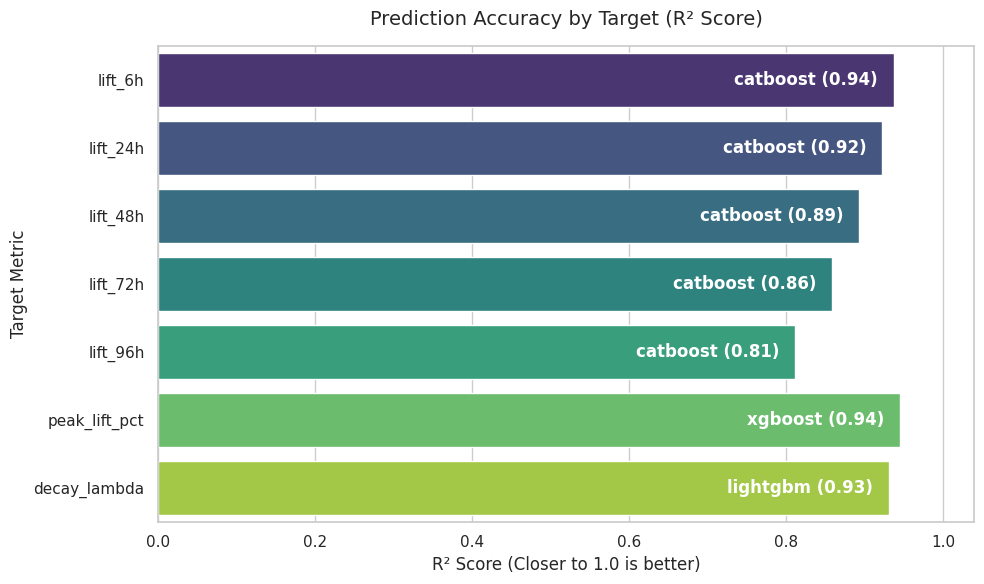

✅ Saved Plot 1: target_performance.png


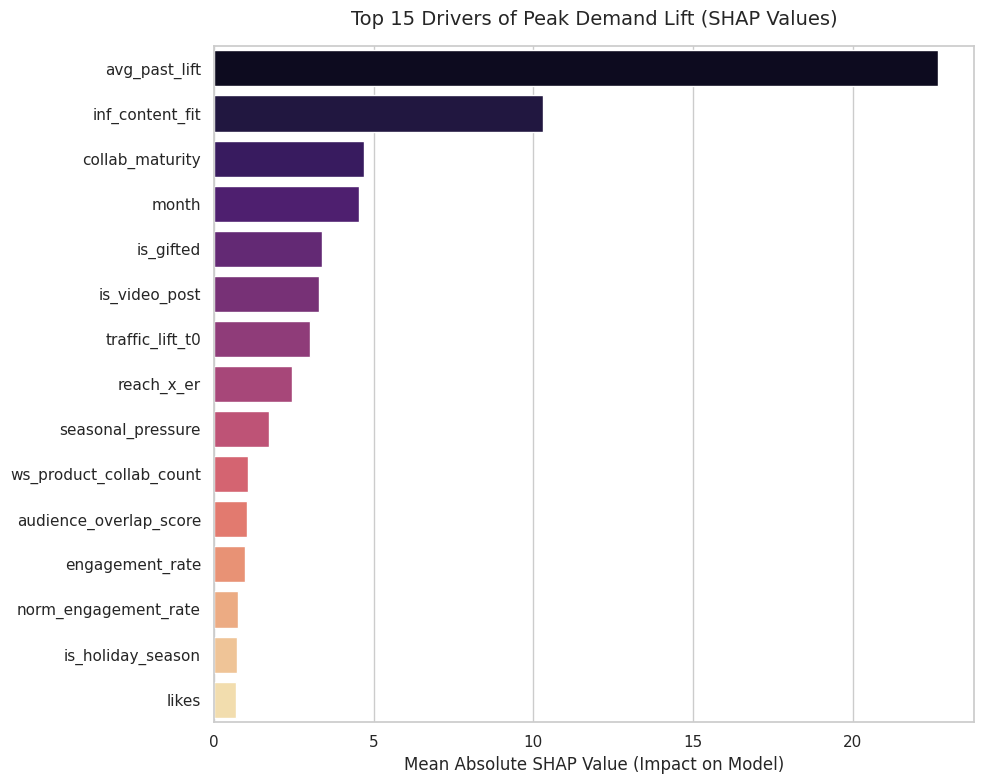

✅ Saved Plot 2: shap_feature_importance.png


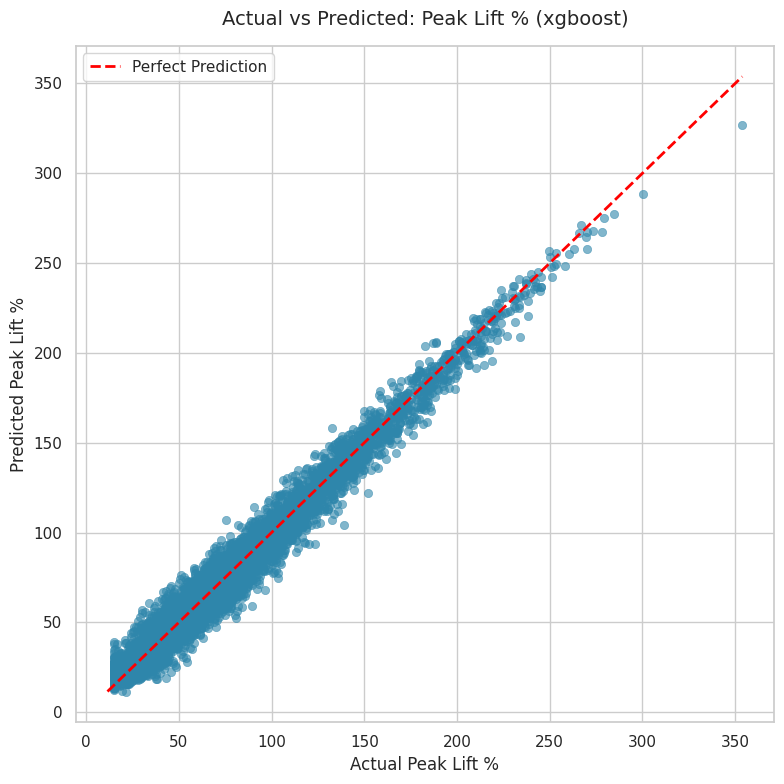

✅ Saved Plot 3: actual_vs_predicted.png

All visualizations complete! Check the /models folder.


In [14]:
"""
Generate Visualizations for Influencer Demand Forecasting
========================================================
Reads the outputs from train_model_optimized.py and
generates 3 performance plots using Matplotlib & Seaborn.

Run
---
  pip install matplotlib seaborn pandas
  python generate_visualizations.py
"""

import os
import json
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
MODEL_DIR = "models"
INPUT_FILE = "features_engineered.csv"

print("Generating visualizations...")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 1: Model Performance across all Targets (R² Score)
# ─────────────────────────────────────────────────────────────────────────────
with open('training_results.json', 'r') as f:
    results = json.load(f)

targets = []
r2_scores = []
best_models = []

for target, metrics in results.items():
    best_model = metrics['best_model']
    targets.append(target)
    r2_scores.append(metrics[best_model]['r2'])
    best_models.append(best_model)

plt.figure(figsize=(10, 6))
# Create bar plot
bars = sns.barplot(x=r2_scores, y=targets, palette="viridis")

# Add the name of the winning model text to each bar
for i, bar in enumerate(bars.patches):
    plt.text(bar.get_width() - 0.02,
             bar.get_y() + bar.get_height() / 2,
             f"{best_models[i]} ({r2_scores[i]:.2f})",
             va='center', ha='right', color='white', fontweight='bold')

plt.title('Prediction Accuracy by Target (R² Score)', fontsize=14, pad=15)
plt.xlabel('R² Score (Closer to 1.0 is better)', fontsize=12)
plt.ylabel('Target Metric', fontsize=12)
plt.xlim(0, max(r2_scores) * 1.1)  # Give a little padding on the right
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, '01_target_performance.png'), dpi=300)
plt.show()
print("✅ Saved Plot 1: target_performance.png")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 2: SHAP Feature Importance for Peak Lift %
# ─────────────────────────────────────────────────────────────────────────────
shap_file = os.path.join(MODEL_DIR, 'shap_importance_peak_lift.csv')
if os.path.exists(shap_file):
    shap_df = pd.read_csv(shap_file).head(15) # Grab top 15

    plt.figure(figsize=(10, 8))
    sns.barplot(x='mean_abs_shap', y='feature', data=shap_df, palette="magma")

    plt.title('Top 15 Drivers of Peak Demand Lift (SHAP Values)', fontsize=14, pad=15)
    plt.xlabel('Mean Absolute SHAP Value (Impact on Model)', fontsize=12)
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, '02_shap_feature_importance.png'), dpi=300)
    plt.show()
    print("✅ Saved Plot 2: shap_feature_importance.png")
else:
    print("⚠️ Skipping Plot 2: SHAP CSV not found.")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 3: Actual vs. Predicted Scatter Plot (peak_lift_pct)
# ─────────────────────────────────────────────────────────────────────────────
target_to_plot = 'peak_lift_pct'
best_model_name = results[target_to_plot]['best_model']

# Load the dataset
df = pd.read_csv(INPUT_FILE)
# Filter to WS posts just like the training script did
ws_df = df[df["ws_flag"] == 1].copy()

# Load the model and features
model_path = os.path.join(MODEL_DIR, f"{target_to_plot}_best.pkl")
features_path = os.path.join(MODEL_DIR, f"{target_to_plot}_features.json")

if os.path.exists(model_path) and os.path.exists(features_path):
    with open(model_path, 'rb') as f:
        best_model = pickle.load(f)
    with open(features_path, 'r') as f:
        features = json.load(f)

    # Generate Predictions
    y_actual = ws_df[target_to_plot]
    y_pred = best_model.predict(ws_df[features])

    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=y_actual, y=y_pred, alpha=0.6, color="#2E86AB", edgecolor=None)

    # Plot the "Perfect Prediction" diagonal line
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

    plt.title(f'Actual vs Predicted: Peak Lift % ({best_model_name})', fontsize=14, pad=15)
    plt.xlabel('Actual Peak Lift %', fontsize=12)
    plt.ylabel('Predicted Peak Lift %', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, '03_actual_vs_predicted.png'), dpi=300)
    plt.show()
    print("✅ Saved Plot 3: actual_vs_predicted.png")
else:
    print(f"⚠️ Skipping Plot 3: Could not find model files for {target_to_plot}")

print("\nAll visualizations complete! Check the /models folder.")